# REPORT: Data Cleaning and Feature Engineering
## Project: Forecast Restaurant Visitors with Time Series Analysis

This notebook performs the full cleaning pipeline and feature engineering workflow before forecasting.

**Input:** raw CSV files from `./raw_Data/`
**Output:** cleaned data saved to `./processed_data/`


---
## 4. Data Cleaning

This section checks data quality issues before modeling. The cleaned outputs are written to `processed_data/` and are used by the later forecasting notebook.


### 4.1 Reload the Raw Data

To keep the workflow reproducible, the raw CSV files are read again and all type conversions are applied explicitly here rather than relying on in-memory state from earlier analysis.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
BASE_DIR = Path.cwd()
NOTEBOOK_DIR = BASE_DIR if (BASE_DIR / 'raw_Data').exists() else BASE_DIR / 'notebooks'
rpath = str(NOTEBOOK_DIR / 'raw_Data') + '/'
ppath = str(NOTEBOOK_DIR / 'processed_data') + '/'

# ===== Load raw CSV =====
air_visits  = pd.read_csv(os.path.join(rpath, "air_visit_data.csv"))
air_reserve = pd.read_csv(os.path.join(rpath, "air_reserve.csv"))
hpg_reserve = pd.read_csv(os.path.join(rpath, "hpg_reserve.csv"))
air_store   = pd.read_csv(os.path.join(rpath, "air_store_info.csv"))
hpg_store   = pd.read_csv(os.path.join(rpath, "hpg_store_info.csv"))
holidays    = pd.read_csv(os.path.join(rpath, "date_info.csv"))
store_ids   = pd.read_csv(os.path.join(rpath, "store_id_relation.csv"))

# ===== Type conversion =====
air_visits["visit_date"]        = pd.to_datetime(air_visits["visit_date"])
air_reserve["visit_datetime"]   = pd.to_datetime(air_reserve["visit_datetime"])
air_reserve["reserve_datetime"] = pd.to_datetime(air_reserve["reserve_datetime"])
hpg_reserve["visit_datetime"]   = pd.to_datetime(hpg_reserve["visit_datetime"])
hpg_reserve["reserve_datetime"] = pd.to_datetime(hpg_reserve["reserve_datetime"])

air_store["air_genre_name"] = air_store["air_genre_name"].astype("category")
air_store["air_area_name"]  = air_store["air_area_name"].astype("category")
hpg_store["hpg_genre_name"] = hpg_store["hpg_genre_name"].astype("category")
hpg_store["hpg_area_name"]  = hpg_store["hpg_area_name"].astype("category")

holidays["holiday_flg"] = holidays["holiday_flg"].astype(bool)
holidays["date"]        = pd.to_datetime(holidays["calendar_date"])

wday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
air_visits["wday"]  = pd.Categorical(
    air_visits["visit_date"].dt.day_name().str[:3],
    categories=wday_order, ordered=True
)
air_visits["month"] = air_visits["visit_date"].dt.month_name().str[:3]

print("Du lieu da load lai tu CSV goc:")
for name, df in [
    ("air_visits", air_visits), ("air_reserve", air_reserve), ("hpg_reserve", hpg_reserve),
    ("air_store", air_store),   ("hpg_store", hpg_store),     ("holidays", holidays),
    ("store_ids", store_ids),
]:
    print(f"  {name:<15} {df.shape[0]:>8,} rows  {df.shape[1]:>2} cols")

Du lieu da load lai tu CSV goc:
  air_visits       252,108 rows   5 cols
  air_reserve       92,378 rows   4 cols
  hpg_reserve     2,000,320 rows   4 cols
  air_store            829 rows   5 cols
  hpg_store          4,690 rows   5 cols
  holidays             517 rows   4 cols
  store_ids            150 rows   2 cols


**Notes:** The raw data has been reloaded successfully with the intended standardized types. This is the reproducible starting point for the full cleaning pipeline.


### 4.2 Detect and Remove Duplicate Records

Online reservation systems often produce duplicate rows because of retries or repeat submissions. This section handles both exact duplicates and key-level duplicates.


In [2]:
# ===== Exact duplicates =====
air_exact = air_reserve.duplicated().sum()
hpg_exact = hpg_reserve.duplicated().sum()

# ===== Key-level duplicates =====
key_air = ["air_store_id", "visit_datetime", "reserve_datetime"]
key_hpg = ["hpg_store_id", "visit_datetime", "reserve_datetime"]
air_key_dup = air_reserve.duplicated(subset=key_air, keep=False).sum()
hpg_key_dup = hpg_reserve.duplicated(subset=key_hpg, keep=False).sum()

# ===== air_visits: (store, date) phai duy nhat =====
av_key_dup = air_visits.duplicated(subset=["air_store_id", "visit_date"]).sum()

print(f"{'Dataset':<20} {'Exact dup':>10} {'Key dup':>10}")
print("-" * 45)
print(f"{'air_visits':<20} {'--':>10} {av_key_dup:>10,}  (store+date)")
print(f"{'air_reserve':<20} {air_exact:>10,} {air_key_dup:>10,}")
print(f"{'hpg_reserve':<20} {hpg_exact:>10,} {hpg_key_dup:>10,}")

Dataset               Exact dup    Key dup
---------------------------------------------
air_visits                   --          0  (store+date)
air_reserve               2,770     11,433
hpg_reserve              16,279     39,844


In [3]:
n_air_before = len(air_reserve)
n_hpg_before = len(hpg_reserve)

# Buoc 1: Xoa exact duplicates
air_reserve = air_reserve.drop_duplicates()
hpg_reserve = hpg_reserve.drop_duplicates()

# Buoc 2: Key-level — giu ban ghi co reserve_visitors lon nhat
air_reserve = (
    air_reserve
    .sort_values("reserve_visitors", ascending=False)
    .drop_duplicates(subset=key_air, keep="first")
    .reset_index(drop=True)
)
hpg_reserve = (
    hpg_reserve
    .sort_values("reserve_visitors", ascending=False)
    .drop_duplicates(subset=key_hpg, keep="first")
    .reset_index(drop=True)
)

print("=== KET QUA SAU XU LY TRUNG LAP ===")
print(f"air_reserve : {n_air_before:,} -> {len(air_reserve):,}  (xoa {n_air_before - len(air_reserve):,})")
print(f"hpg_reserve : {n_hpg_before:,} -> {len(hpg_reserve):,}  (xoa {n_hpg_before - len(hpg_reserve):,})")

=== KET QUA SAU XU LY TRUNG LAP ===
air_reserve : 92,378 -> 85,703  (xoa 6,675)
hpg_reserve : 2,000,320 -> 1,980,105  (xoa 20,215)


**Notes:** Reservation data contains a meaningful number of duplicates. After cleaning, each booking key is represented by one retained record.


### 4.3 Detect and Treat Outliers in `visitors`

This section uses a per-store IQR rule so that large stores are not incorrectly flagged by a global threshold. Extreme values are capped rather than deleted to preserve time-series continuity.


So ban ghi outlier: 852   |   So nha hang bi anh huong: 303

=== DANH SACH OUTLIER (giam dan theo visitors) ===
        air_store_id visit_date  visitors  upper
air_cfdeb326418194ff 2017-03-08       877     70
air_8c3175aa5e4fc569 2017-04-18       777     85
air_f2985de32bb792e0 2016-07-10       675    112
air_eca5e0064dc9314a 2016-08-30       627     99
air_43d577e0c9460e64 2016-01-24       514    101
air_9828505fefc77d75 2016-11-19       409     50
air_e42bdc3377d1eee7 2016-12-14       372     58
air_cb083b4789a8d3a2 2016-01-14       369     90
air_07bb665f9cdfbdfb 2016-08-07       351     81
air_c6aa2efba0ffc8eb 2017-01-23       348     85
air_81bd68142db76f58 2017-03-28       335    116
air_d98380a4aeb0290b 2016-12-24       328    112
air_eca5e0064dc9314a 2016-09-08       325     99
air_eca5e0064dc9314a 2016-08-26       325     99
air_4570f52104fe0982 2016-05-01       311     36
air_0919d54f0c9a24b8 2016-11-07       305    159
air_9152d9926e5c4a3a 2016-01-13       269    135
air_51

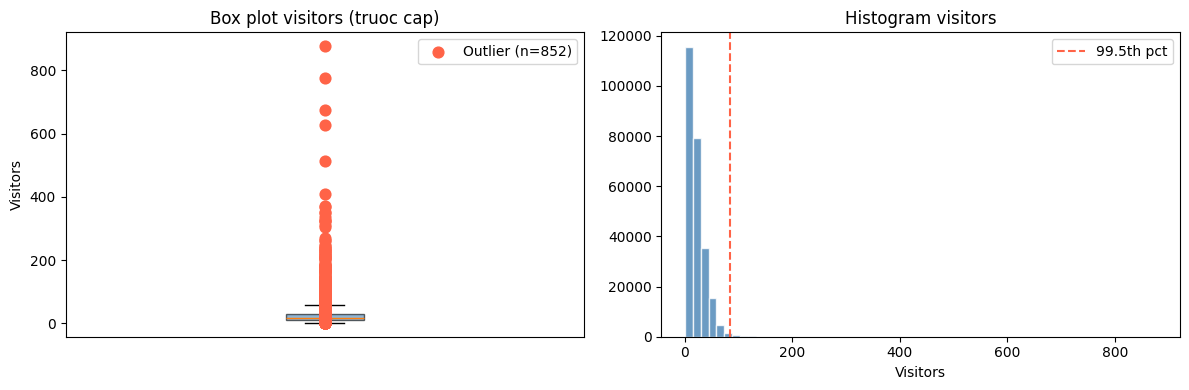

In [4]:
# Tinh per-store IQR fence
store_stats = (
    air_visits
    .groupby("air_store_id")["visitors"]
    .agg(q1=lambda x: x.quantile(0.25),
         q3=lambda x: x.quantile(0.75))
    .reset_index()
)
store_stats["iqr"]   = store_stats["q3"] - store_stats["q1"]
store_stats["upper"] = store_stats["q3"] + 3.0 * store_stats["iqr"]

air_visits = air_visits.merge(store_stats[["air_store_id", "upper"]], on="air_store_id", how="left")
air_visits["is_outlier"] = air_visits["visitors"] > air_visits["upper"]

n_outliers = air_visits["is_outlier"].sum()
n_stores   = air_visits.loc[air_visits["is_outlier"], "air_store_id"].nunique()

print(f"So ban ghi outlier: {n_outliers}   |   So nha hang bi anh huong: {n_stores}")
print()
print("=== DANH SACH OUTLIER (giam dan theo visitors) ===")
out_view = (
    air_visits[air_visits["is_outlier"]]
    [["air_store_id", "visit_date", "visitors", "upper"]]
    .assign(upper=lambda x: x["upper"].round(0).astype(int))
    .sort_values("visitors", ascending=False)
    .head(20)
)
print(out_view.to_string(index=False))

# Box plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.boxplot(air_visits["visitors"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6))
ax1.scatter([1] * n_outliers, air_visits.loc[air_visits["is_outlier"], "visitors"],
            color="tomato", s=60, zorder=5, label=f"Outlier (n={n_outliers})")
ax1.set_title("Box plot visitors (truoc cap)")
ax1.set_ylabel("Visitors")
ax1.set_xticks([])
ax1.legend()

ax2.hist(air_visits["visitors"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(air_visits["visitors"].quantile(0.995), color="tomato",
            linestyle="--", linewidth=1.5, label="99.5th pct")
ax2.set_title("Histogram visitors")
ax2.set_xlabel("Visitors")
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
# Cap outlier tai upper fence
air_visits["visitors"] = air_visits.apply(
    lambda r: r["upper"] if r["is_outlier"] else r["visitors"], axis=1
)
air_visits["visitors"] = air_visits["visitors"].round().astype(int)
air_visits = air_visits.drop(columns=["upper", "is_outlier"])

print("=== THONG KE SAU KHI CAP ===")
print(air_visits["visitors"].describe().round(2))
print(f"\nMax sau khi cap: {air_visits['visitors'].max()}")

=== THONG KE SAU KHI CAP ===
count    252108.00
mean         20.89
std          16.09
min           1.00
25%           9.00
50%          17.00
75%          29.00
max         205.00
Name: visitors, dtype: float64

Max sau khi cap: 205


**Notes:**
- True outliers are limited.
- Capping is safer than deletion for sequential data.
- The per-store rule is conservative enough to avoid over-removing naturally busy days.


### 4.4 Sparse Store Filter

A time-series model needs a minimum amount of history. Stores with fewer than 90 days of data are removed from training.


=== PHAN PHOI SO NGAY DU LIEU THEO NHA HANG ===
count    829.0
mean     304.1
std       93.5
min       20.0
25%      243.0
50%      284.0
75%      391.0
max      477.0
Name: n_days, dtype: float64

Nha hang co < 90 ngay: 15
        air_store_id  n_days
air_900d755ebd2f7bbd      20
air_a9a380530c1e121f      40
air_789103bf53b8096b      41
air_a17f0778617c76e2      47
air_1c0b150f9e696a5f      51
air_cf5ab75a0afb8af9      53
air_8e492076a1179383      54
air_8e8f42f047537154      62
air_bb4ff06cd661ee9b      66
air_8110d68cc869b85e      69
air_9c6787aa03a45586      70
air_52a08ef3efdb4bb0      72
air_2703dcb33192b181      79
air_6b65745d432fd77f      81
air_28dbe91c4c9656be      83


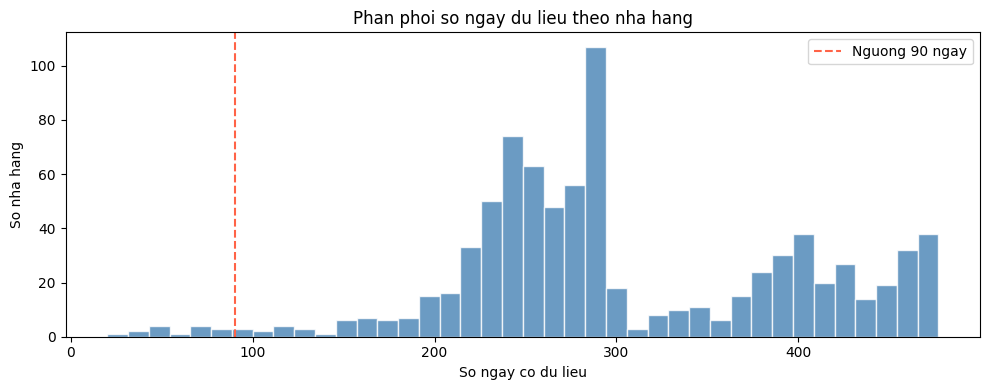

In [6]:
store_day_counts = (
    air_visits
    .groupby("air_store_id")["visit_date"]
    .count()
    .rename("n_days")
    .reset_index()
    .sort_values("n_days")
)

THRESHOLD = 90
sparse = store_day_counts[store_day_counts["n_days"] < THRESHOLD]

print("=== PHAN PHOI SO NGAY DU LIEU THEO NHA HANG ===")
print(store_day_counts["n_days"].describe().round(1))
print(f"\nNha hang co < {THRESHOLD} ngay: {len(sparse)}")
if len(sparse) > 0:
    print(sparse.to_string(index=False))
else:
    print("  (khong co)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(store_day_counts["n_days"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(THRESHOLD, color="tomato", linestyle="--", linewidth=1.5, label=f"Nguong {THRESHOLD} ngay")
ax.set_title("Phan phoi so ngay du lieu theo nha hang")
ax.set_xlabel("So ngay co du lieu")
ax.set_ylabel("So nha hang")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
n_before_s = air_visits["air_store_id"].nunique()
n_before_r = len(air_visits)

valid_stores = store_day_counts.loc[store_day_counts["n_days"] >= THRESHOLD, "air_store_id"]
air_visits = air_visits[air_visits["air_store_id"].isin(valid_stores)].reset_index(drop=True)

print(f"air_visits:")
print(f"  So nha hang : {n_before_s} -> {air_visits['air_store_id'].nunique()}")
print(f"  So ban ghi  : {n_before_r:,} -> {len(air_visits):,}")

air_visits:
  So nha hang : 829 -> 814
  So ban ghi  : 252,108 -> 251,220


**Notes:** Most stores have enough history. Stores removed by this filter are typically too new to contribute reliable signal.


### 4.5 Temporal Alignment Checks

This section verifies holiday coverage and removes reservations with impossible lead times or clearly invalid temporal ordering.


In [8]:
visits_min = air_visits["visit_date"].min()
visits_max = air_visits["visit_date"].max()
hol_min    = holidays["date"].min()
hol_max    = holidays["date"].max()

print("=== PHAM VI THOI GIAN ===")
print(f"air_visits : {visits_min.date()} -> {visits_max.date()}")
print(f"holidays   : {hol_min.date()} -> {hol_max.date()}")
print(f"Holidays phu het training window: {hol_min <= visits_min and hol_max >= visits_max}")

# Lead time check
air_reserve["lead_time_h"] = (
    (air_reserve["visit_datetime"] - air_reserve["reserve_datetime"])
    .dt.total_seconds() / 3600
)
extreme = (air_reserve["lead_time_h"] > 365 * 24).sum()
negative = (air_reserve["lead_time_h"] < 0).sum()

print(f"\nair_reserve lead time > 1 nam  : {extreme:,}")
print(f"air_reserve lead time < 0 (loi): {negative:,}")

n_before = len(air_reserve)
air_reserve = air_reserve[
    (air_reserve["lead_time_h"] >= 0) &
    (air_reserve["lead_time_h"] <= 365 * 24)
].reset_index(drop=True)
air_reserve = air_reserve.drop(columns=["lead_time_h"])

if n_before != len(air_reserve):
    print(f"Sau khi loc lead time: {n_before:,} -> {len(air_reserve):,}")

# Test-period reservations (giu lai)
air_beyond = (air_reserve["visit_datetime"].dt.normalize() > visits_max).sum()
print(f"\nDat ban co visit_date trong test period (sau {visits_max.date()}): {air_beyond:,}")
print("  -> Giu lai de lam feature cho tap test.")

=== PHAM VI THOI GIAN ===
air_visits : 2016-01-01 -> 2017-04-22
holidays   : 2016-01-01 -> 2017-05-31
Holidays phu het training window: True

air_reserve lead time > 1 nam  : 42
air_reserve lead time < 0 (loi): 0
Sau khi loc lead time: 85,703 -> 85,661

Dat ban co visit_date trong test period (sau 2017-04-22): 1,752
  -> Giu lai de lam feature cho tap test.


**Notes:**
- Holiday coverage spans the full train and test windows.
- Reservation records in later periods can still be useful for feature engineering.
- Invalid lead times are removed as system errors.


### 4.6 Save the Cleaned Data


In [9]:
from IPython.display import display

summary = pd.DataFrame({
    "Dataset":  ["air_visits", "air_visits", "air_reserve", "hpg_reserve", "Cac file khac"],
    "Van de":   [
        "Outlier per-store (Q3 + 3xIQR)",
        "Sparse store (< 90 ngay)",
        "Trung lap + lead time bat thuong",
        "Trung lap",
        "Khong co van de",
    ],
    "Xu ly":    [
        "Cap tai upper fence",
        "Loai nha hang khoi training set",
        "drop_duplicates + giu max visitors + xoa lead>1 nam",
        "drop_duplicates + giu max visitors",
        "Giu nguyen",
    ],
})
print("=== TONG KET DATA CLEANING ===")
display(summary)

# ===== Luu ra processed_data/ =====
import os
os.makedirs(ppath, exist_ok=True)

air_visits .to_csv(os.path.join(ppath, "air_visits.csv"),  index=False)
air_reserve.to_csv(os.path.join(ppath, "air_reserve.csv"), index=False)
hpg_reserve.to_csv(os.path.join(ppath, "hpg_reserve.csv"), index=False)
air_store  .to_csv(os.path.join(ppath, "air_store.csv"),   index=False)
hpg_store  .to_csv(os.path.join(ppath, "hpg_store.csv"),   index=False)
holidays   .to_csv(os.path.join(ppath, "holidays.csv"),    index=False)
store_ids  .to_csv(os.path.join(ppath, "store_ids.csv"),   index=False)

print("\n=== DA LUU VAO processed_data/ ===")
for fname in sorted(os.listdir(ppath)):
    fpath = os.path.join(ppath, fname)
    # Skip subdirectories (e.g., the 'fe' folder)
    if not os.path.isfile(fpath):
        continue
    n = sum(1 for _ in open(fpath, encoding="utf-8")) - 1
    ncols = len(pd.read_csv(fpath, nrows=0).columns)
    print(f"  {fname:<28} {n:>8,} rows  {ncols:>2} cols")


=== TONG KET DATA CLEANING ===


,Dataset,Van de,Xu ly
0,air_visits,Outlier per-store (Q3 + 3xIQR),Cap tai upper fence
1,air_visits,Sparse store (< 90 ngay),Loai nha hang khoi training set
2,air_reserve,Trung lap + lead time bat thuong,drop_duplicates + giu max visitors + xoa lead>...
3,hpg_reserve,Trung lap,drop_duplicates + giu max visitors
4,Cac file khac,Khong co van de,Giu nguyen



=== DA LUU VAO processed_data/ ===
  air_reserve.csv                85,661 rows   4 cols
  air_store.csv                     829 rows   5 cols
  air_visits.csv                251,220 rows   5 cols
  holidays.csv                      517 rows   4 cols
  hpg_reserve.csv              1,980,105 rows   4 cols
  hpg_store.csv                   4,690 rows   5 cols
  store_ids.csv                     150 rows   2 cols


**The cleaned data has been saved to `processed_data/`.**

Subsequent analysis and modeling should read from this folder so that raw and processed data remain clearly separated.

---
## 5. Exploratory Analysis on Cleaned Data


---
## 5. Feature Engineering

This section builds the features used later in forecasting. The aggregate workflow is kept for exploratory reference, while the final notebook applies the same logic at the store-day level.


### 5.1 Load the Cleaned Data


In [10]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd()
NOTEBOOK_DIR = BASE_DIR if (BASE_DIR / "processed_data").exists() else BASE_DIR / "notebooks"
ppath = str(NOTEBOOK_DIR / "processed_data")
fe_path = os.path.join(ppath, "fe")
os.makedirs(fe_path, exist_ok=True)

# ?? Load cleaned data ??????????????????????????????????????????????????????
air_visits  = pd.read_csv(os.path.join(ppath, "air_visits.csv"),  parse_dates=["visit_date"])
air_reserve = pd.read_csv(os.path.join(ppath, "air_reserve.csv"),
                          parse_dates=["visit_datetime", "reserve_datetime"])
hpg_reserve = pd.read_csv(os.path.join(ppath, "hpg_reserve.csv"),
                          parse_dates=["visit_datetime", "reserve_datetime"])
holidays    = pd.read_csv(os.path.join(ppath, "holidays.csv"),    parse_dates=["date"])

holidays["holiday_flg"] = holidays["holiday_flg"].astype(bool)
air_reserve = pd.read_csv(os.path.join(ppath, "air_reserve.csv"),
                          parse_dates=["visit_datetime", "reserve_datetime"])
hpg_reserve = pd.read_csv(os.path.join(ppath, "hpg_reserve.csv"),
                          parse_dates=["visit_datetime", "reserve_datetime"])
holidays    = pd.read_csv(os.path.join(ppath, "holidays.csv"),    parse_dates=["date"])

holidays["holiday_flg"] = holidays["holiday_flg"].astype(bool)

# ── Aggregate daily total visitors (tất cả nhà hàng) ─────────────────────
daily = (
    air_visits
    .groupby("visit_date", as_index=False)["visitors"]
    .sum()
    .rename(columns={"visit_date": "date", "visitors": "total_visitors"})
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Daily series: {len(daily)} ngày  |  {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Visitors:  min={daily['total_visitors'].min()}  max={daily['total_visitors'].max()}  mean={daily['total_visitors'].mean():.1f}")


Daily series: 478 ngày  |  2016-01-01 → 2017-04-22
Visitors:  min=1000  max=23836  mean=10931.0


**Notes:** The cleaned data is aggregated into a daily series here for exploratory feature analysis and as a reference for the final ARIMAX exogenous design.


### 5.2 Target Variable: `log1p` Transform

The daily visitor total is right-skewed, so `log1p` is used to stabilize variance, reduce outlier impact, and align the optimization scale more closely with RMSLE.


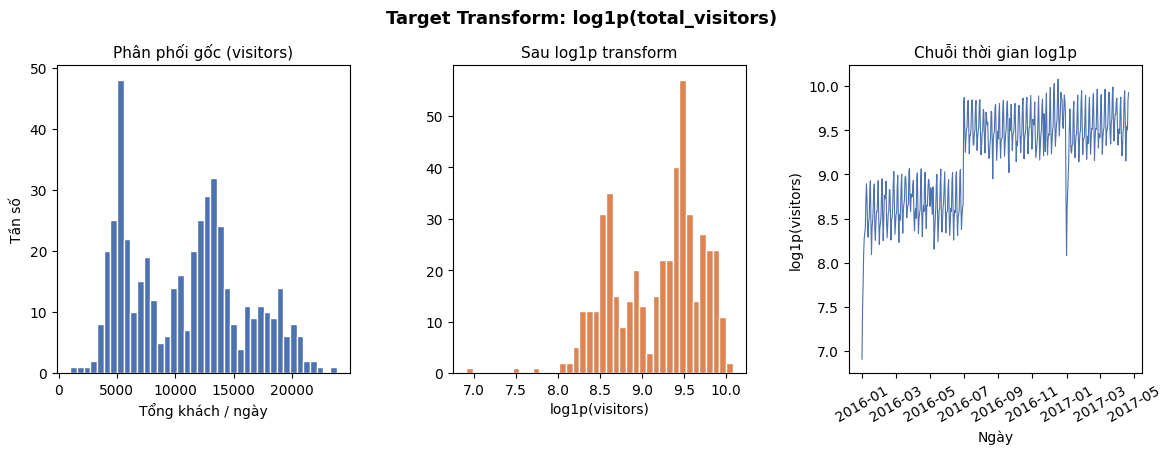

Skewness gốc: 0.243   → after log1p: -0.541


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Log1p transform ────────────────────────────────────────────────────────
daily["log1p_visitors"] = np.log1p(daily["total_visitors"])

# ── Visualise before / after ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

# Histogram original
ax0.hist(daily["total_visitors"], bins=40, color="#4C72B0", edgecolor="white")
ax0.set_title("Phân phối gốc (visitors)", fontsize=11)
ax0.set_xlabel("Tổng khách / ngày"); ax0.set_ylabel("Tần số")

# Histogram log1p
ax1.hist(daily["log1p_visitors"], bins=40, color="#DD8452", edgecolor="white")
ax1.set_title("Sau log1p transform", fontsize=11)
ax1.set_xlabel("log1p(visitors)")

# Time series log1p
ax2.plot(daily["date"], daily["log1p_visitors"], lw=0.8, color="#4C72B0")
ax2.set_title("Chuỗi thời gian log1p", fontsize=11)
ax2.set_xlabel("Ngày"); ax2.set_ylabel("log1p(visitors)")
ax2.tick_params(axis='x', rotation=30)

plt.suptitle("Target Transform: log1p(total_visitors)", fontsize=13, fontweight="bold", y=1.02)
plt.savefig(os.path.join(fe_path, "target_transform.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Skewness gốc:", round(daily['total_visitors'].skew(), 3),
      "  → after log1p:", round(daily['log1p_visitors'].skew(), 3))


**Notes:** After `log1p`, the distribution is more symmetric and more suitable for ARIMAX-style modeling and RMSLE-based evaluation.


### 5.3 Calendar Features

Calendar features help the model represent within-week and within-year seasonality, including weekday structure, weekends, and month-level effects.


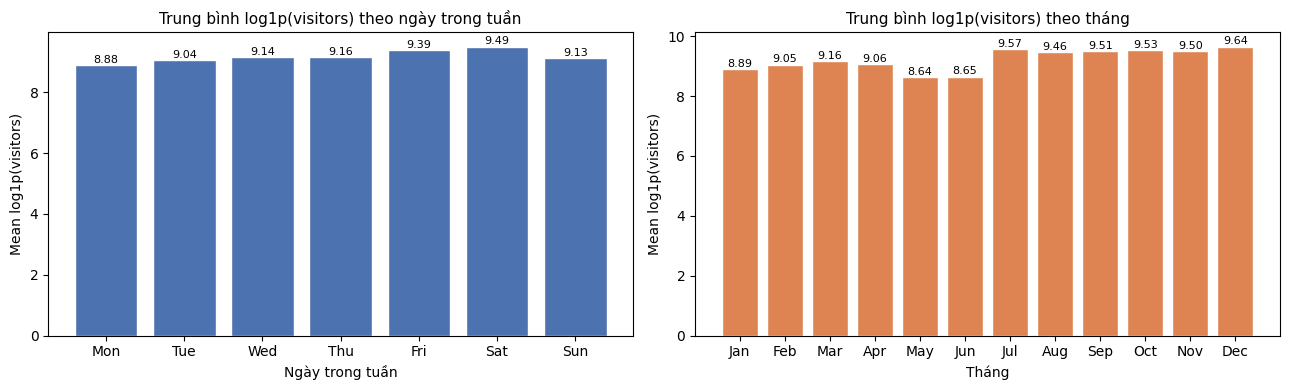

In [12]:
# ── Calendar features ─────────────────────────────────────────────────────
daily["wday"]       = daily["date"].dt.dayofweek           # 0=Mon … 6=Sun
daily["is_weekend"] = (daily["wday"] >= 5).astype(int)    # Sat=5, Sun=6
daily["month"]      = daily["date"].dt.month
daily["year"]       = daily["date"].dt.year

# ── Visualise mean visitors by weekday and month ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

wday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
wday_mean   = daily.groupby("wday")["log1p_visitors"].mean()
axes[0].bar(wday_labels, wday_mean.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Trung bình log1p(visitors) theo ngày trong tuần", fontsize=11)
axes[0].set_xlabel("Ngày trong tuần"); axes[0].set_ylabel("Mean log1p(visitors)")
for i, v in enumerate(wday_mean.values):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_mean   = daily.groupby("month")["log1p_visitors"].mean()
axes[1].bar(month_labels[:len(month_mean)], month_mean.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Trung bình log1p(visitors) theo tháng", fontsize=11)
axes[1].set_xlabel("Tháng"); axes[1].set_ylabel("Mean log1p(visitors)")
for i, v in enumerate(month_mean.values):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(fe_path, "calendar_patterns.png"), dpi=120, bbox_inches="tight")
plt.show()


**Notes:** Weekend effects are the strongest and most stable seasonal signal in the data. Monthly effects exist, but are weaker and less uniform.


### 5.4 Holiday and Event Features

This section separates ordinary national holidays from Golden Week so the final model can represent them as distinct intervention-style features.


is_holiday:     31 ngày lễ quốc gia
is_golden_week: 7 ngày trong Golden Week windows
Prophet holidays DataFrame: 38 rows (legacy exploratory output)



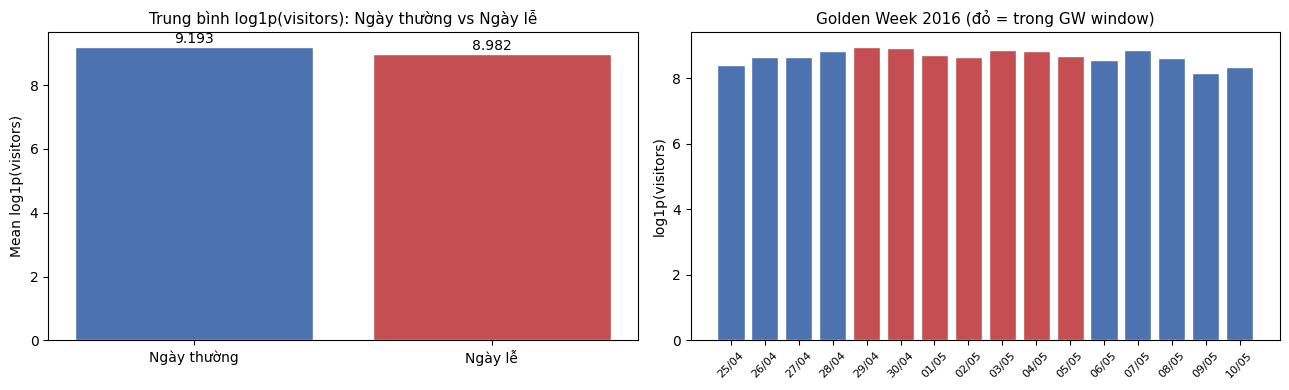

In [13]:
# ── is_holiday: từ date_info.csv ─────────────────────────────────────────
hol_map = holidays.set_index("date")["holiday_flg"]
daily["is_holiday"] = daily["date"].map(hol_map).fillna(False).astype(int)

# ── is_golden_week: Apr 29 – May 5 mỗi năm ───────────────────────────────
daily["is_golden_week"] = (
    ((daily["date"].dt.month == 4) & (daily["date"].dt.day >= 29)) |
    ((daily["date"].dt.month == 5) & (daily["date"].dt.day <= 5))
).astype(int)

# ── Tạo holiday DataFrame legacy cho exploratory workflow ───────────────
# Các file này được giữ lại để tham chiếu, không dùng trong so sánh mô hình cuối
# Tách Golden Week ra khỏi tập holiday thường để workflow exploratory học riêng
jp_holidays = holidays[holidays["holiday_flg"]].copy()
jp_holidays = jp_holidays.rename(columns={"date": "ds"})
jp_holidays["holiday"] = "jp_holiday"

gw_dates = daily[daily["is_golden_week"] == 1][["date"]].rename(columns={"date": "ds"})
gw_dates["holiday"] = "golden_week"

# Gộp và dedup (Golden Week có thể trùng với holiday thường)
prophet_holidays = (
    pd.concat([jp_holidays[["ds","holiday"]], gw_dates], ignore_index=True)
    .drop_duplicates(subset="ds")
    .sort_values("ds")
    .reset_index(drop=True)
)

# ── Summary ────────────────────────────────────────────────────────────────
print(f"is_holiday:     {daily['is_holiday'].sum()} ngày lễ quốc gia")
print(f"is_golden_week: {daily['is_golden_week'].sum()} ngày trong Golden Week windows")
print(f"Prophet holidays DataFrame: {len(prophet_holidays)} rows (legacy exploratory output)")
print()

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Holiday vs non-holiday
hol_compare = daily.groupby("is_holiday")["log1p_visitors"].mean()
axes[0].bar(["Ngày thường", "Ngày lễ"], hol_compare.values, color=["#4C72B0","#C44E52"], edgecolor="white")
axes[0].set_title("Trung bình log1p(visitors): Ngày thường vs Ngày lễ", fontsize=11)
axes[0].set_ylabel("Mean log1p(visitors)")
for i, v in enumerate(hol_compare.values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

# Golden Week window
gw_mask = (daily["date"] >= "2016-04-25") & (daily["date"] <= "2016-05-10")
gw_window = daily[gw_mask].copy()
colors = gw_window["is_golden_week"].map({1:"#C44E52", 0:"#4C72B0"})
axes[1].bar(range(len(gw_window)), gw_window["log1p_visitors"], color=colors, edgecolor="white")
axes[1].set_title("Golden Week 2016 (đỏ = trong GW window)", fontsize=11)
axes[1].set_xticks(range(len(gw_window)))
axes[1].set_xticklabels(gw_window["date"].dt.strftime("%d/%m"), rotation=45, fontsize=8)
axes[1].set_ylabel("log1p(visitors)")

plt.tight_layout()
plt.savefig(os.path.join(fe_path, "holiday_features.png"), dpi=120, bbox_inches="tight")
plt.show()


**Notes:** Holiday effects are not identical to weekend effects, and Golden Week is strong enough to justify its own dedicated feature.


### 5.5 Reservation Lead Indicator

Reservation data is a valid leading indicator because reservations are observed before the visit date. This section aggregates reservation counts by planned visit date.


HPG reserve đã được join thành công qua store_id_relation
Ngày có reservation data: 478/478 (100.0%)
Mean reserve/ngày: 1052.7


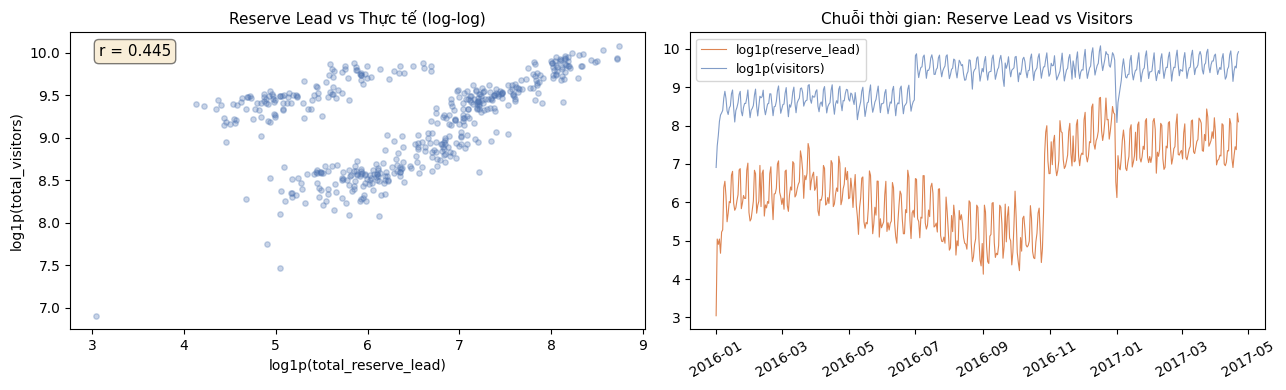

In [14]:
# ── Aggregate AIR reserve_visitors theo visit_date ────────────────────────
air_reserve["visit_date"] = air_reserve["visit_datetime"].dt.normalize()

reserve_daily = (
    air_reserve
    .groupby("visit_date", as_index=False)["reserve_visitors"]
    .sum()
    .rename(columns={"visit_date": "date", "reserve_visitors": "air_reserve_lead"})
)

# ── HPG reserve: map qua store_id_relation rồi add vào (nếu có link) ─────
try:
    store_ids = pd.read_csv(os.path.join(ppath, "store_ids.csv"))
    hpg_reserve["visit_date"] = hpg_reserve["visit_datetime"].dt.normalize()
    hpg_daily = (
        hpg_reserve
        .merge(store_ids, on="hpg_store_id", how="inner")  # chỉ giữ HPG có AIR id
        .groupby("visit_date", as_index=False)["reserve_visitors"]
        .sum()
        .rename(columns={"visit_date": "date", "reserve_visitors": "hpg_reserve_lead"})
    )
    reserve_daily = reserve_daily.merge(hpg_daily, on="date", how="outer").fillna(0)
    reserve_daily["total_reserve_lead"] = (
        reserve_daily["air_reserve_lead"] + reserve_daily["hpg_reserve_lead"]
    )
    print("HPG reserve đã được join thành công qua store_id_relation")
except Exception as e:
    reserve_daily["total_reserve_lead"] = reserve_daily["air_reserve_lead"]
    print(f"Dùng AIR reserve only: {e}")

# ── Merge vào daily ────────────────────────────────────────────────────────
daily = daily.merge(reserve_daily[["date","air_reserve_lead","total_reserve_lead"]],
                    on="date", how="left")
daily["air_reserve_lead"]   = daily["air_reserve_lead"].fillna(0)
daily["total_reserve_lead"] = daily["total_reserve_lead"].fillna(0)

# ── Log1p transform của reserve (xử lý zero-inflation) ───────────────────
daily["log1p_reserve"] = np.log1p(daily["total_reserve_lead"])

# ── Coverage check ─────────────────────────────────────────────────────────
n_with_reserve = (daily["total_reserve_lead"] > 0).sum()
print(f"Ngày có reservation data: {n_with_reserve}/{len(daily)} ({100*n_with_reserve/len(daily):.1f}%)")
print(f"Mean reserve/ngày: {daily['total_reserve_lead'].mean():.1f}")

# ── Visualise correlation reserve → visitors ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(daily["log1p_reserve"], daily["log1p_visitors"],
                alpha=0.3, s=15, color="#4C72B0")
axes[0].set_xlabel("log1p(total_reserve_lead)")
axes[0].set_ylabel("log1p(total_visitors)")
axes[0].set_title("Reserve Lead vs Thực tế (log-log)", fontsize=11)
corr = daily[["log1p_reserve","log1p_visitors"]].corr().iloc[0,1]
axes[0].text(0.05, 0.92, f"r = {corr:.3f}", transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

axes[1].plot(daily["date"], daily["log1p_reserve"], lw=0.8, color="#DD8452", label="log1p(reserve_lead)")
axes[1].plot(daily["date"], daily["log1p_visitors"], lw=0.8, color="#4C72B0", label="log1p(visitors)", alpha=0.7)
axes[1].set_title("Chuỗi thời gian: Reserve Lead vs Visitors", fontsize=11)
axes[1].legend(fontsize=9); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(fe_path, "reserve_lead.png"), dpi=120, bbox_inches="tight")
plt.show()


**Notes:** `log1p_reserve` is informative but incomplete, because many store-days have no reservation records. It is therefore used as an exogenous regressor rather than a target proxy.


### 5.6 Build the Master Feature Table


=== MASTER FEATURE TABLE ===
Shape: (478, 12)

Missing values:
Series([], dtype: int64)
(Không có missing values)



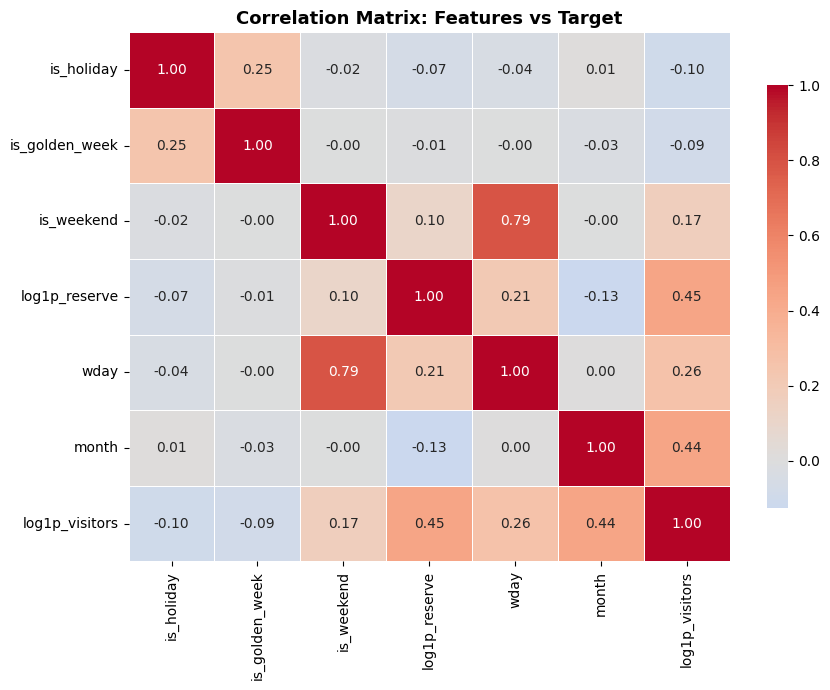


Feature summary:
       is_holiday  is_golden_week  is_weekend  log1p_reserve     wday  \
count     478.000         478.000     478.000        478.000  478.000   
mean        0.065           0.015       0.287          6.440    3.006   
std         0.247           0.120       0.453          1.065    2.001   
min         0.000           0.000       0.000          3.045    0.000   
25%         0.000           0.000       0.000          5.622    1.000   
50%         0.000           0.000       0.000          6.400    3.000   
75%         0.000           0.000       1.000          7.216    5.000   
max         1.000           1.000       1.000          8.736    6.000   

         month  log1p_visitors  total_visitors  
count  478.000         478.000          478.00  
mean     5.548           9.179        10930.99  
std      3.531           0.517         4977.60  
min      1.000           6.909         1000.00  
25%      3.000           8.670         5827.25  
50%      5.000           9.337

In [15]:
# ── Kiểm tra missing values ─────────────────────────────────────────────
print("=== MASTER FEATURE TABLE ===")
print(f"Shape: {daily.shape}")
print()
print("Missing values:")
print(daily.isnull().sum()[daily.isnull().sum() > 0])
print("(Không có missing values)" if daily.isnull().sum().sum() == 0 else "")
print()

# ── Correlation matrix giữa các exogenous features ───────────────────────
exog_cols = ["is_holiday", "is_golden_week", "is_weekend", "log1p_reserve",
             "wday", "month"]
corr_mat = daily[exog_cols + ["log1p_visitors"]].corr()

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix: Features vs Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(fe_path, "correlation_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()

print()
print("Feature summary:")
print(daily[exog_cols + ["log1p_visitors","total_visitors"]].describe().round(3))


**Notes:** The combined feature table confirms that weekend indicators are the strongest simple drivers, while holiday and reservation variables add complementary signal.


### 5.7 Export Model-Specific Datasets


In [16]:
# ── (A) Chuỗi univariate cho baseline Seasonal Naive ────────────────────
ts_sarima_ets = daily[["date", "total_visitors", "log1p_visitors"]].copy()
ts_sarima_ets.to_csv(os.path.join(fe_path, "ts_sarima_ets.csv"), index=False)
print(f"ts_sarima_ets.csv     : {len(ts_sarima_ets)} rows, cols: {list(ts_sarima_ets.columns)}")

# ── (B) ARIMAX: chuỗi + exogenous variables ───────────────────────────────
# Exog: is_holiday, is_golden_week, is_weekend, log1p_reserve
# Baseline seasonal-naive dùng trực tiếp lag 7; không cần exogenous
ts_arimax = daily[[
    "date", "total_visitors", "log1p_visitors",
    "is_holiday", "is_golden_week", "is_weekend", "log1p_reserve"
]].copy()
ts_arimax.to_csv(os.path.join(fe_path, "ts_arimax.csv"), index=False)
print(f"ts_arimax.csv         : {len(ts_arimax)} rows, cols: {list(ts_arimax.columns)}")

# ── (C) Prophet legacy output: ds/y format + optional regressors ─────────
ts_prophet = daily[[
    "date", "log1p_visitors",
    "is_weekend", "log1p_reserve"
]].rename(columns={"date": "ds", "log1p_visitors": "y"}).copy()
ts_prophet.to_csv(os.path.join(fe_path, "ts_prophet.csv"), index=False)
print(f"ts_prophet.csv        : {len(ts_prophet)} rows, cols: {list(ts_prophet.columns)}")

# ── (D) Prophet holidays DataFrame (legacy) ──────────────────────────────
# Giữ lại cho exploratory archive; không dùng ở kết quả cuối
prophet_holidays_out = prophet_holidays.copy()
prophet_holidays_out["lower_window"] = prophet_holidays_out["holiday"].map(
    {"jp_holiday": -1, "golden_week": -2}
)
prophet_holidays_out["upper_window"] = prophet_holidays_out["holiday"].map(
    {"jp_holiday":  1, "golden_week":  2}
)
prophet_holidays_out.to_csv(os.path.join(fe_path, "prophet_holidays.csv"), index=False)
print(f"prophet_holidays.csv  : {len(prophet_holidays_out)} rows, cols: {list(prophet_holidays_out.columns)}")

# ── (E) Master feature table ──────────────────────────────────────────────
daily.to_csv(os.path.join(fe_path, "daily_features.csv"), index=False)
print(f"daily_features.csv    : {len(daily)} rows, cols: {list(daily.columns)}")

print()
print("=== TẤT CẢ FILES ĐÃ LƯU VÀO processed_data/fe/ ===")
for fname in sorted(os.listdir(fe_path)):
    fpath = os.path.join(fe_path, fname)
    if fname.endswith(".csv"):
        n = sum(1 for _ in open(fpath, encoding="utf-8")) - 1
        ncols = len(pd.read_csv(fpath, nrows=0).columns)
        print(f"  {fname:<30} {n:>6} rows  {ncols:>2} cols")


ts_sarima_ets.csv     : 478 rows, cols: ['date', 'total_visitors', 'log1p_visitors']
ts_arimax.csv         : 478 rows, cols: ['date', 'total_visitors', 'log1p_visitors', 'is_holiday', 'is_golden_week', 'is_weekend', 'log1p_reserve']
ts_prophet.csv        : 478 rows, cols: ['ds', 'y', 'is_weekend', 'log1p_reserve']
prophet_holidays.csv  : 38 rows, cols: ['ds', 'holiday', 'lower_window', 'upper_window']
daily_features.csv    : 478 rows, cols: ['date', 'total_visitors', 'log1p_visitors', 'wday', 'is_weekend', 'month', 'year', 'is_holiday', 'is_golden_week', 'air_reserve_lead', 'total_reserve_lead', 'log1p_reserve']

=== TẤT CẢ FILES ĐÃ LƯU VÀO processed_data/fe/ ===
  daily_features.csv                478 rows  12 cols
  prophet_holidays.csv               38 rows   4 cols
  ts_arimax.csv                     478 rows   7 cols
  ts_prophet.csv                    478 rows   4 cols
  ts_sarima_ets.csv                 478 rows   3 cols


**Notes:** Separate output files are created for the baseline and the final model so that feature engineering and modeling remain cleanly separated.


### 5.8 Feature Engineering Summary

The final engineered variables include the transformed target, calendar variables, holiday indicators, and reservation-based leading indicators that support the final store-level forecasting notebook.
